# 4 · Volba jazyka zadání

**Odpovídá sekci 4.2 práce — Strategie 1**, část *Volba jazyka zadání*
(Obrázek 4.3).

Odborná literatura uvádí, že jazykové modely dosahují nejvyšších analytických
schopností v angličtině. Zpracovávané faktury ale obsahují velké množství
specifických českých pojmů — „stočné“, „rezervovaná kapacita“, „spalné teplo“ —
u nichž překlad zavádí riziko chyby.

**Otázka:** Ovlivňuje jazyk zadání přesnost extrakce natolik, aby na něm záleželo?

## Testované varianty

| Varianta | Instrukce | Názvy hledaných polí | Očekávané riziko |
|---|---|---|---|
| **en** | anglicky | anglicky | model musí text faktury vnitřně překládat |
| **cs** | česky | česky | model řeší úkol v jazyce, který pro něj není hlavní |
| **cs_en** | anglicky | česky | kombinace — má spojit výhody obou |

| | |
|---|---|
| **Datová sada** | DS2 |
| **Upstream** | fixováno z notebooků `02` a `03` (P4 + JSON-light) |
| **Metrika** | F1 skóre, průměr přes všechny promptovací strategie |

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

KOREN = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(KOREN / "experiments"))

from thesis_style import *          # noqa: F403
pouzij_styl()

DATA = KOREN / "experiments" / "data"
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("Data:", DATA.relative_to(KOREN))

Data: experiments\data


In [2]:
jazyk = pd.read_csv(DATA / "04_jazyk_promptu" / "prompt_benchmark_full.csv")
PORADI_JAZYKU = ["en", "cs_en", "cs"]
NAZVY_JAZYKU = {"en": "en\n(anglicky)", "cs_en": "cs_en\n(kombinovaně)", "cs": "cs\n(česky)"}
ZVOLENY = "cs_en"

print(f"jazykových variant : {jazyk.prompt_language.nunique()}")
print(f"dokumentů          : {jazyk.invoice_idx.nunique()}")
print(f"měření             : {len(jazyk)}")

jazykových variant : 3
dokumentů          : 180
měření             : 1620


## 4.1 Přesnost podle jazyka zadání (Obrázek 4.3 v práci)

Chybové úsečky ukazují směrodatnou odchylku mezi jednotlivými fakturami. Pokud
je rozdíl mezi variantami menší než rozptyl uvnitř každé z nich, je volba jazyka
z hlediska přesnosti nerozhodná.

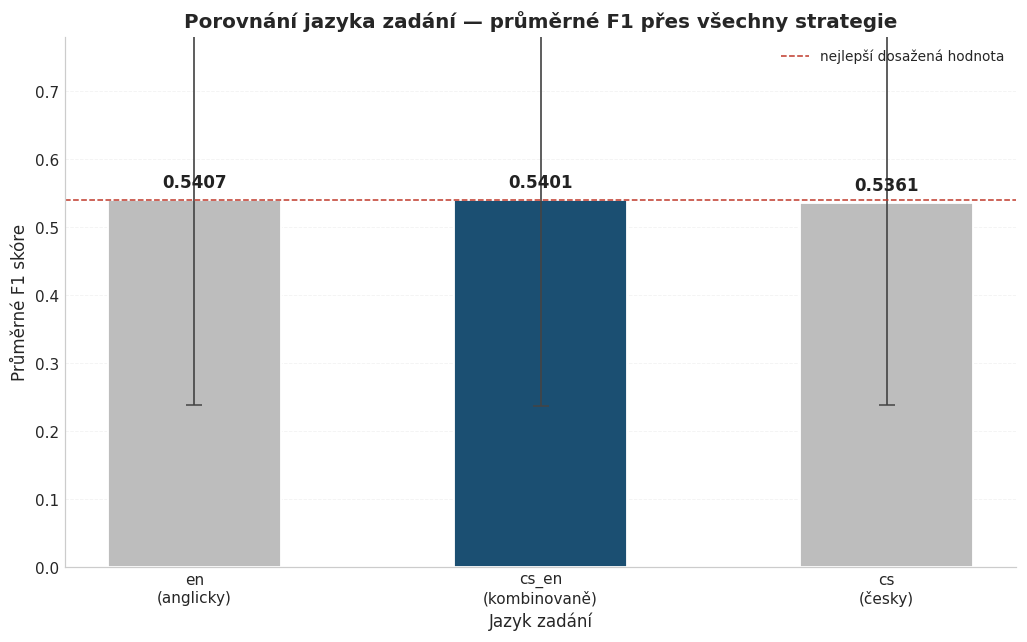

Rozdíl mezi nejlepší a nejhorší variantou: 0.46 procentního bodu
Směrodatná odchylka uvnitř variant:        30.0 p. b.


,F1,odchylka,precision,recall,null_rate,tokeny,n
prompt_language,,,,,,,
en,0.5407,0.3013,0.4385,0.7575,0.0610,4332.6944,540
cs_en,0.5401,0.3028,0.4417,0.7565,0.0641,4346.0278,540
cs,0.5361,0.2966,0.4364,0.7555,0.0720,4715.8611,540


In [3]:
souhrn = (jazyk.groupby("prompt_language")
               .agg(F1=("f1", "mean"), odchylka=("f1", "std"),
                    precision=("precision", "mean"), recall=("recall", "mean"),
                    null_rate=("null_rate", "mean"), tokeny=("prompt_tokens", "mean"),
                    n=("f1", "size"))
               .reindex(PORADI_JAZYKU))

fig, ax = plt.subplots(figsize=(9.5, 6))
barvy = barvy_vitez(PORADI_JAZYKU, vitez=ZVOLENY)
sloupce = ax.bar([NAZVY_JAZYKU[j] for j in PORADI_JAZYKU], souhrn.F1,
                 yerr=souhrn.odchylka, color=barvy, width=0.5,
                 edgecolor="white", linewidth=1.2,
                 error_kw=dict(ecolor="#444444", lw=1.1, capsize=5))
for sloupec, hodnota in zip(sloupce, souhrn.F1):
    ax.text(sloupec.get_x() + sloupec.get_width() / 2, hodnota + 0.012,
            f"{hodnota:.4f}", ha="center", va="bottom",
            fontsize=11, fontweight="700", color="#222222")

ax.axhline(souhrn.F1.max(), color=PRAH, linestyle="--", linewidth=1.0,
           label="nejlepší dosažená hodnota")
ax.set_ylim(0, 0.78)
uprav_osu(ax, "Porovnání jazyka zadání — průměrné F1 přes všechny strategie",
          x="Jazyk zadání", y="Průměrné F1 skóre")
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

rozpeti = (souhrn.F1.max() - souhrn.F1.min()) * 100
print(f"Rozdíl mezi nejlepší a nejhorší variantou: {rozpeti:.2f} procentního bodu")
print(f"Směrodatná odchylka uvnitř variant:        {souhrn.odchylka.mean() * 100:.1f} p. b.")
display(tabulka(souhrn.round(4), desetinna=4))

> **Zjištění.** Rozdíly v přesnosti jsou zanedbatelné — méně než jeden procentní
> bod — a mnohonásobně menší než rozptyl mezi jednotlivými fakturami. Volba jazyka
> tedy sama o sobě výsledek nerozhoduje.

## 4.2 Chová se některý jazyk lépe u degradovaných skenů?

Průměr může zakrývat rozdíly uvnitř skupin. Následující rozpad ověřuje, zda se
některá varianta neprosadí alespoň u obtížnějších dokumentů nebo u konkrétní
komodity.

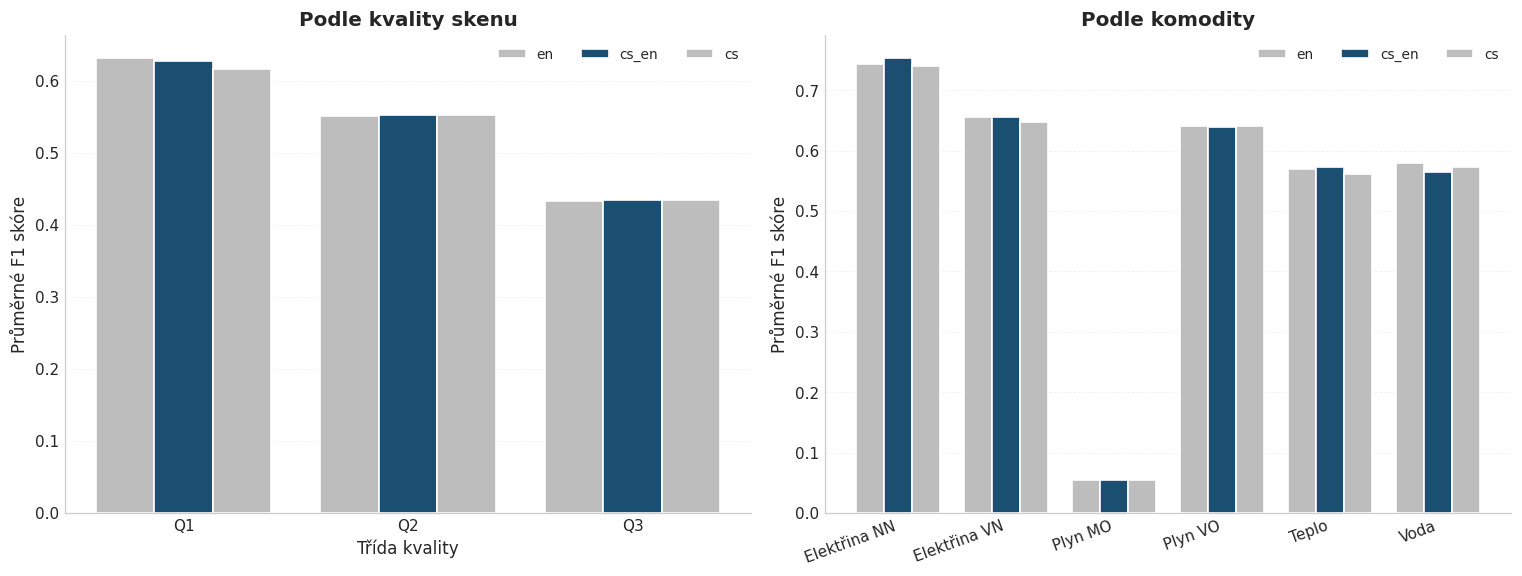

Rozpětí mezi jazyky [p. b.]:
  napříč třídami kvality : 0.65
  napříč komoditami      : 0.86


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.4))

dle_kvality = (jazyk.pivot_table(index="quality", columns="prompt_language",
                                 values="f1", aggfunc="mean")[PORADI_JAZYKU])
x, sirka = np.arange(len(dle_kvality)), 0.26
for i, j in enumerate(PORADI_JAZYKU):
    ax1.bar(x + (i - 1) * sirka, dle_kvality[j], sirka, label=j,
            color=barvy_vitez(PORADI_JAZYKU, ZVOLENY)[i],
            edgecolor="white", linewidth=1.1)
ax1.set_xticks(x)
ax1.set_xticklabels(dle_kvality.index)
uprav_osu(ax1, "Podle kvality skenu", x="Třída kvality", y="Průměrné F1 skóre")
ax1.legend(frameon=False, fontsize=9, ncol=3)
ax1.grid(axis="x", visible=False)

dle_komodity = (jazyk.pivot_table(index="commodity", columns="prompt_language",
                                  values="f1", aggfunc="mean")
                     .reindex(KOMODITY)[PORADI_JAZYKU])
x = np.arange(len(dle_komodity))
for i, j in enumerate(PORADI_JAZYKU):
    ax2.bar(x + (i - 1) * sirka, dle_komodity[j], sirka, label=j,
            color=barvy_vitez(PORADI_JAZYKU, ZVOLENY)[i],
            edgecolor="white", linewidth=1.1)
ax2.set_xticks(x)
ax2.set_xticklabels([NAZVY_KOMODIT[k] for k in dle_komodity.index],
                    rotation=20, ha="right")
uprav_osu(ax2, "Podle komodity", y="Průměrné F1 skóre")
ax2.legend(frameon=False, fontsize=9, ncol=3)
ax2.grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

print("Rozpětí mezi jazyky [p. b.]:")
print(f"  napříč třídami kvality : {(dle_kvality.max(axis=1) - dle_kvality.min(axis=1)).mean() * 100:.2f}")
print(f"  napříč komoditami      : {(dle_komodity.max(axis=1) - dle_komodity.min(axis=1)).mean() * 100:.2f}")

## Závěr

**Zvolená varianta: `cs_en` — instrukce anglicky, názvy polí česky.**

Rozdíly mezi jazyky jsou statisticky nevýznamné, volba se proto opírá o věcnou
úvahu, nikoli o naměřený rozdíl:

* **angličtina v instrukcích** využívá jazyk, ve kterém model uvažuje nejspolehlivěji,
* **čeština v názvech polí** odstraňuje mezikrok překladu odborných pojmů,
  a tím i riziko, že model přiřadí hodnotu ke špatnému poli.

Varianta se fixuje pro notebooky `05`–`08` i pro produkční pipeline.